### Notebook for plotting/analyzing impacts of different terms of Wave-Action Equation

In [97]:
from scipy.io import loadmat, savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import sys
import os
import haversine
import xarray as xr
from haversine import haversine, Unit
from src.find_phase_inds import find_phase_inds
import matplotlib.gridspec as gridspec

#DEFINE ykm and xkm grid
ww3_data_control = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))

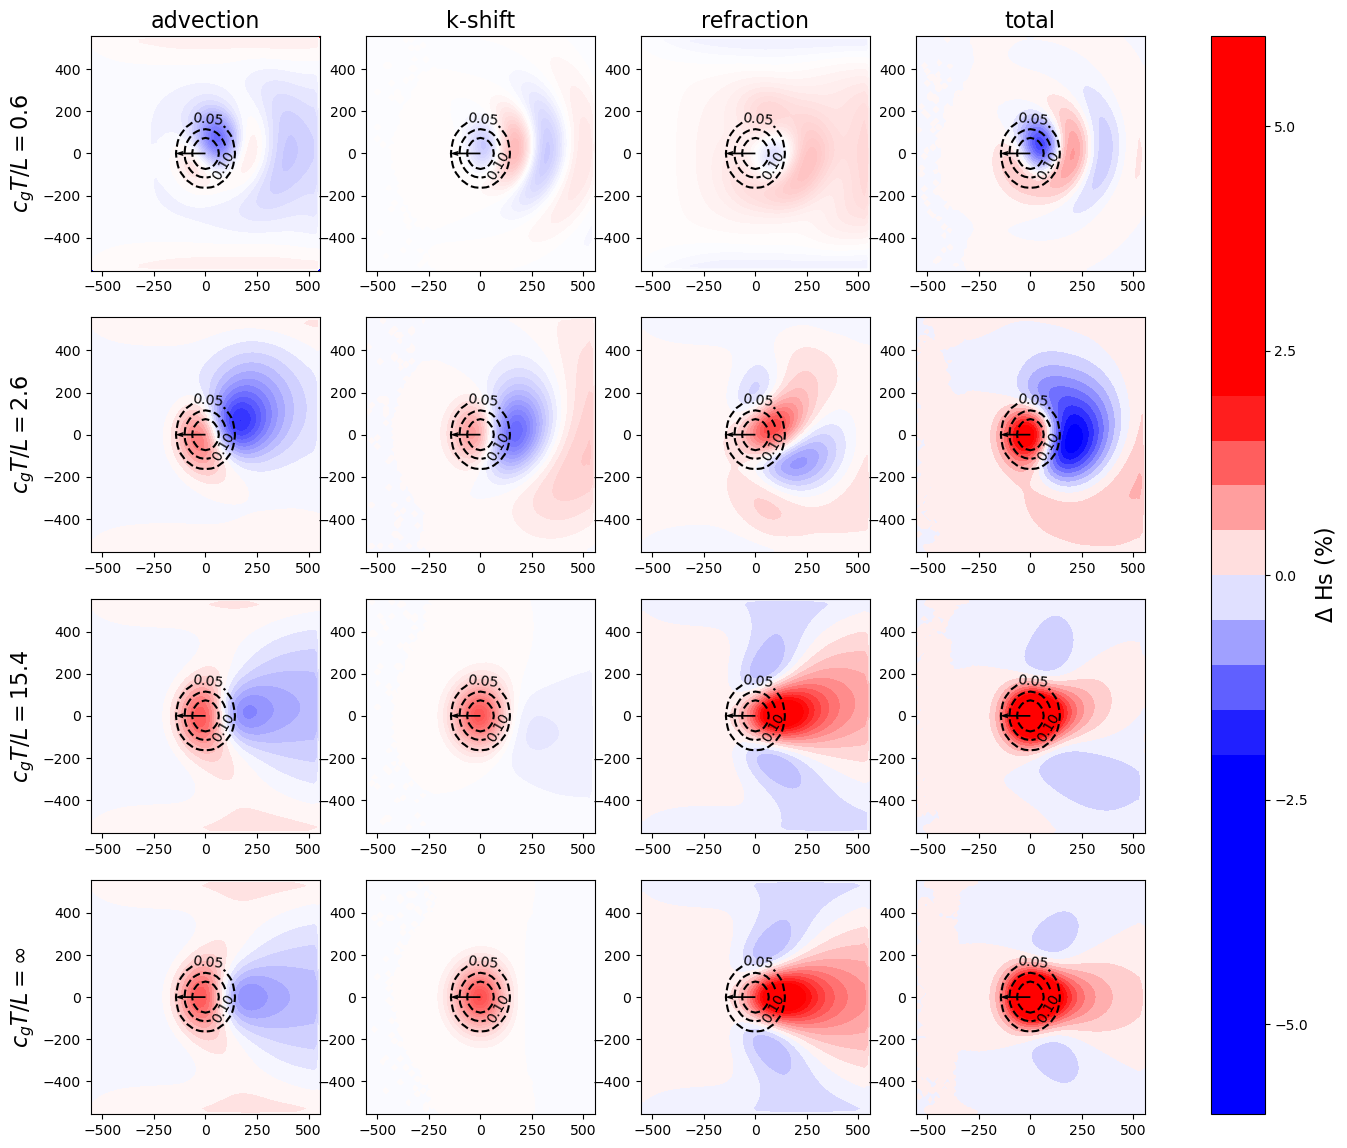

In [100]:
"""

Make figure that top panel is cur = 200, Tp=5s
bottom panel is cur = 50, Tp = 15s
"""


#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
cur_files = ["100_12", "100_48","100_288", "100_steady_west"] #Current Widths
runs = ["advec", "advec_k", "advec_th", "all_cur"] #Different physics parameters
runs_labels = ["advection", "k-shift", "refraction", "total"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]

fig, ax = plt.subplots(len(cur_files), len(runs), figsize=(17, 14)) # Make figure

bc = "BC_10"
test=np.linspace(-10, 10, len(xkm)*len(ykm))
fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-2, vmax=2, levels=40, cmap='bwr')
for i in range(len(cur_files)):
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0

   
    
    #Get cur name
    cur = cur_files[i]
    #Calc cgT/L
    
    if "100_steady" in cur:
        cgt_l = "$\infty$"
    else:
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = 0.19*cg*Ti/L
        cgt_l = f"{cgt_l:.1f}"
        
    ax[i, 0].set_ylabel("$c_{g}T/L =$" + cgt_l, fontsize=16)
    for run_i in range(len(runs)):
         #calc cgT/L
       
        run = runs[run_i]
        data = xr.open_dataset(spath+bc+"/"+cur+"/"+run+".nc")
        inds = find_phase_inds(data, "west", 0.2)
        #full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        if (run == "advec_k") or (run=="advec_th"):
            control = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        else:
            control = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"no_cur"+".nc")
        anom = 100*(data.hs - control.hs)/control.hs
        #full_anom = full.hs - control.hs
        
        cm = ax[i, col_count].contourf(xkm, ykm, anom[inds[-1], :, :], levels=20, vmin=-2, vmax=2, cmap='bwr')
        ax[i, run_i].quiver(xkm[40], ykm[40], data.ucur[inds[-1], 40, 40], data.vcur[inds[-1], 40, 40], scale=1.5)
        cs = ax[i, run_i].contour(xkm, ykm, np.sqrt(data.ucur[inds[-1], :, :]**2+data.vcur[inds[-1], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[i, run_i].clabel(cs, fontsize=10)
        #ax[i, col_count].quiver(xkm, ykm, data.ucur[inds[-1], ::4, ::4], data.vcur[inds[-1], ::4, ::4], scale=1.5)
        if i==0:
            ax[i, col_count].set_title(runs_labels[run_i], fontsize=16)
        col_count+=1
        #plt.colorbar(cm)

cbar= fig.colorbar(fake_cbar, ax=ax)
cbar.ax.set_ylim(-6,6)
cbar.ax.set_ylabel(r"$\Delta$ Hs (%)", fontsize=16)


plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/phys_contributions_maps.png", bbox_inches='tight')



Text(0.5, 1.0, 'Explained variance of Hs anomaly, by term in wave-action equation')

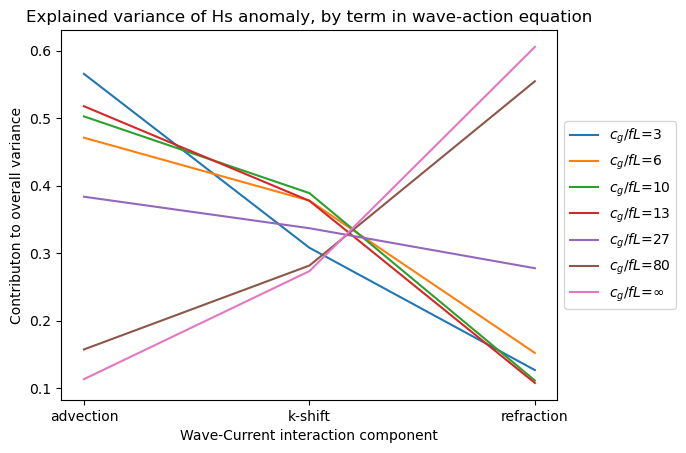

In [9]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
runs = ["advec", "advec_k", "advec_th"] #Different physics parameters
runs_labels = ["advection", "k-shift", "refraction"]
cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
advec_array = np.array([])
k_array = np.array([])
th_array = np.array([])
#var_array # Do total variance too
#fig, ax = plt.subplots(5, len(runs), figsize=(15, 20)) # Make figure
#inds = [1588, 1592, 1595, 1599]
#w_inds = np.zeros(len(inds), dtype=int)
#w_inds[0] = int(np.where(data.time==data.time[inds[0]])[0][0])+2 
bc = "BC_10"
for i in range(len(cur_files)):
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0

    #Get cur name
    cur = cur_files[i]
    #Load all the files for each current configuration
    full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
    data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
    data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
    data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
    control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
    control_nc = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"no_cur"+".nc")

    #Calculate the anomalies
    anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
    anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
    anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs
    
    anom_advec = data_advec.hs - control_nc.hs
    anom_k = data_k.hs - data_advec.hs
    anom_th = data_th.hs - data_advec.hs
    
    inds = find_phase_inds(data_advec, "west", 0.2)
        
    full_anom = full.hs - control_nc.hs
    
    varY = full_anom[inds[-1], :, :].var(skipna=True)
    covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
    covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
    covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])

    advec_array = np.append(advec_array, np.array([covAdvec/varY]))
    k_array = np.append(k_array, np.array([covK/varY]))
    th_array = np.append(th_array, np.array([covTh/varY]))


    plt.plot(runs_labels, np.array([covAdvec/varY, covK/varY, covTh/varY]), label=cur_labels[i])

plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel("Contributon to overall variance")
plt.xlabel("Wave-Current interaction component")
plt.title("Explained variance of Hs anomaly, by term in wave-action equation")

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/phys_contributions_lineplot.png", bbox_inches='tight')


In [51]:
#Make Dataframe for Hs impacts
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
columns = ["cgT/L","cg", "Ti", "L", "U", "varY", "covAdvec", "covK", "covTh"]
impact_df = pd.DataFrame(columns=columns)

# #params
# folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
# cur_files = ["100", "200"] #Current Widths
# #cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
# runs = ["all_cur"] #Different physics parameters
# for bc in folders:
#     for cur in cur_files:
        
#         full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+cur+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur.nc")
#         data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
#         data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
#         data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
#         control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
     
        

#         #Calculate the relative contributions
#         #Calculate the anomalies
#         anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
#         anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
#         anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs
        
#         anom_advec = data_advec.hs - control_nc.hs
#         anom_k = data_k.hs - data_advec.hs
#         anom_th = data_th.hs - data_advec.hs
        
#         inds = find_phase_inds(data_advec, "west", 0.2)
            
#         full_anom = full.hs - control_nc.hs
        
#         varY = full_anom[inds[-1], :, :].var(skipna=True)
#         covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
#         covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
#         covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])
        
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur)*1000
#         Ti = 14.15*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)
        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, varY.values, covAdvec.values, covK.values, covTh.values]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

#folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
folders=["BC_10"]
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288"]
for bc in folders:
    for cur in cur_files:
        full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control_nc = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
        steady = xr.open_dataset(spath+bc+"/"+"100_steady_west/all_cur.nc")
        data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
        data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
        control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
        #Calculate the contributions
        
        #Calculate the relative contributions
        #Calculate the anomalies
        anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
        anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
        anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs
        
        anom_advec = data_advec.hs - control_nc.hs
        anom_k = data_k.hs - data_advec.hs
        anom_th = data_th.hs - data_advec.hs
        
        inds = find_phase_inds(data_advec, "west", 0.2)
            
        full_anom = full.hs - control_nc.hs
        inds = inds[inds<len(full_anom.time)]
        varY = full_anom[inds[-1], :, :].var(skipna=True)
        covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
        covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
        covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])
    
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, varY.values, covAdvec.values, covK.values, covTh.values]], columns=columns)
        impact_df = pd.concat([impact_df, row], ignore_index=True)


# folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
# #bc = "BC_10"
# cur_files = ["100_12_05", "100_24_05", "100_36_05", "100_48_05", "100_96_05"]
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+"100_steady_west_05/all_cur.nc")
#         inds = find_phase_inds(data, "west", 0.5)
#         inds = inds[inds>500]
#         anom = data.hs-control.hs
#         steady_anom = steady.hs - control.hs
#         var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))

#         if cur=="100_288":
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds) :, :].values))))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
#             NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)

#         else:
#             inds = inds[inds<len(steady.time)]
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
#             NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)


#         max_val = np.nanmax(np.abs(anom[inds, :, :]))
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur.split('_')[0])*1000
#         Ti = int(cur.split('_')[1])*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)

        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_87756/4122997367.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impact_df = pd.concat([impact_df, row], ignore_index=True)


In [87]:
#Make Dataframe for Hs impacts
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
columns = ["cgT/L","cg", "Ti", "L", "U", "varY", "covAdvec", "covK", "covTh"]
impact_df_north = pd.DataFrame(columns=columns)

# #params
# folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
# cur_files = ["100", "200"] #Current Widths
# #cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_steady_west"] #Current Widths
# runs = ["all_cur"] #Different physics parameters
# for bc in folders:
#     for cur in cur_files:
        
#         full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+cur+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+cur+"_steady_west/all_cur.nc")
#         data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
#         data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
#         data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
#         control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
     
        

#         #Calculate the relative contributions
#         #Calculate the anomalies
#         anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
#         anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
#         anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs
        
#         anom_advec = data_advec.hs - control_nc.hs
#         anom_k = data_k.hs - data_advec.hs
#         anom_th = data_th.hs - data_advec.hs
        
#         inds = find_phase_inds(data_advec, "west", 0.2)
            
#         full_anom = full.hs - control_nc.hs
        
#         varY = full_anom[inds[-1], :, :].var(skipna=True)
#         covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
#         covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
#         covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])
        
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur)*1000
#         Ti = 14.15*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)
        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, varY.values, covAdvec.values, covK.values, covTh.values]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

#folders = ["BC_15", "BC_10", "BC_5"] #Boundary Conditions (for different peak frequencies
#bc = "BC_10"
folders=["BC_10"]
cur_files = ["100_4", "100_8", "100_12", "100_24", "100_36", "100_48", "100_96", "100_288", "100_576"]
for bc in folders:
    for cur in cur_files:
        full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
        control_nc = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
        steady = xr.open_dataset(spath+bc+"/"+"100_steady_west/all_cur.nc")
        data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
        data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
        control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
        
        #Calculate the contributions
        
        #Calculate the relative contributions
        #Calculate the anomalies
        anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
        anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
        anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs
        
        anom_advec = data_advec.hs - control_nc.hs
        anom_k = data_k.hs - data_advec.hs
        anom_th = data_th.hs - data_advec.hs
        
        inds = find_phase_inds(data_advec, "north", 0.2)
            
        full_anom = full.hs - control_nc.hs
        inds = inds[inds<len(full_anom.time)]
        varY = full_anom[inds[-1], :, :].var(skipna=True)
        covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
        covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
        covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])
    
        #Calcualte non-dim params
        Tp = int(bc.split('_')[1])
        cg = 9.8*Tp/(4*np.pi)
        L = int(cur.split('_')[0])*1000
        Ti = int(cur.split('_')[1])*60*60
        cgt_l = cg*Ti/L
        U = np.nanmax(data.ucur.values)
        
        row = pd.DataFrame([[cgt_l, cg, Ti, L, U, varY.values, covAdvec.values, covK.values, covTh.values]], columns=columns)
        impact_df_north = pd.concat([impact_df_north, row], ignore_index=True)


# folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
# #bc = "BC_10"
# cur_files = ["100_12_05", "100_24_05", "100_36_05", "100_48_05", "100_96_05"]
# for bc in folders:
#     for cur in cur_files:
#         data = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
#         control = xr.open_dataset(spath+bc+"/"+"100_288"+"/no_cur.nc")
#         steady = xr.open_dataset(spath+bc+"/"+"100_steady_west_05/all_cur.nc")
#         inds = find_phase_inds(data, "west", 0.5)
#         inds = inds[inds>500]
#         anom = data.hs-control.hs
#         steady_anom = steady.hs - control.hs
#         var = np.nanmean(np.var(anom[inds, :, :], axis=(1,2)))

#         if cur=="100_288":
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values-steady_anom[800:800+len(inds) :, :].values))))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[800:800+len(inds), :, :]))
#             NRMSE = RMSE/np.nanmax(steady_anom[800:800+len(inds), :, :].values)
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[800:800+len(inds), :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[800:800+len(inds), :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)

#         else:
#             inds = inds[inds<len(steady.time)]
#             RMSE = np.sqrt(np.nanmean((np.square(anom[inds, :, :]-steady_anom[inds, :, :]))))
#             NRMSE = RMSE/np.nanmax(steady_anom[inds, :, :].values)
#             max_diff = np.nanmax(np.abs(anom[inds, :, :]))/np.nanmax(np.abs(steady_anom[inds, :, :]))
#             RMS = np.sqrt(np.nanmean((np.square(anom[inds, :, :].values))))
#             RMS_s = np.sqrt(np.nanmean((np.square(steady_anom[inds, :, :].values))))
#             nvar = var/np.nanmean(np.var(steady_anom[inds, :, :], axis=(1,2)))
#             #put in the apsect ratio calculation
#             dhsdy = np.gradient(anom[inds[-1], :, :], ykm, axis=0)
#             dhsdx = np.gradient(anom[inds[-1], :, :], xkm, axis=1)
#             top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
#             bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
#             ratio = np.sqrt(top/bot)


#         max_val = np.nanmax(np.abs(anom[inds, :, :]))
#         #Calcualte non-dim params
#         Tp = int(bc.split('_')[1])
#         cg = 9.8*Tp/(4*np.pi)
#         L = int(cur.split('_')[0])*1000
#         Ti = int(cur.split('_')[1])*60*60
#         cgt_l = cg*Ti/L
#         U = np.nanmax(data.ucur.values)

        
#         row = pd.DataFrame([[cgt_l, cg, Ti, L, U, NRMSE, RMSE, RMS, RMS_s, max_diff, max_val, var, nvar, ratio]], columns=columns)
#         impact_df = pd.concat([impact_df, row], ignore_index=True)

/var/folders/77/7yfflvs902s95j6rlhb5yn9c0000gn/T/ipykernel_87756/2015181461.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impact_df_north = pd.concat([impact_df_north, row], ignore_index=True)


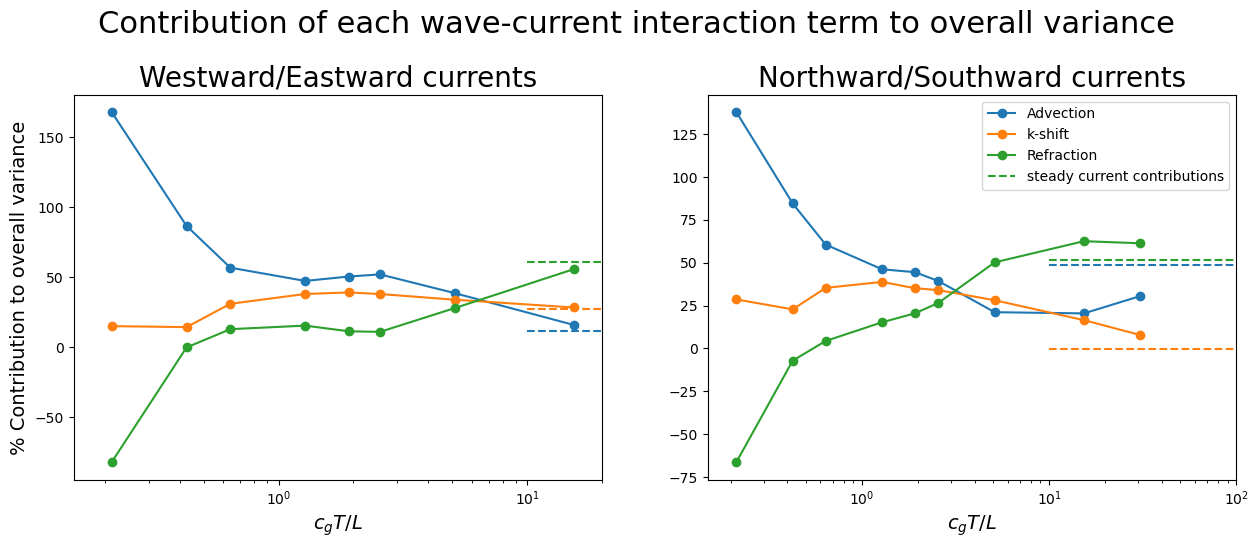

In [102]:
#Calculate steady
cur="100_steady_west"
full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")

#Calculate the contributions

#Calculate the relative contributions
#Calculate the anomalies
anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs

anom_advec = data_advec.hs - control_nc.hs
anom_k = data_k.hs - data_advec.hs
anom_th = data_th.hs - data_advec.hs

inds = find_phase_inds(data_advec, "west", 0.2)
    
full_anom = full.hs - control_nc.hs
inds = inds[inds<len(full_anom.time)]
varY = full_anom[inds[-1], :, :].var(skipna=True)
covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])


fig, ax = plt.subplots(1,2, figsize=(15, 5))
ax[0].plot(impact_df["cgT/L"]*.19, 100*impact_df["covAdvec"]/impact_df["varY"], '-o')
ax[0].plot(impact_df["cgT/L"]*.19, 100*impact_df["covK"]/impact_df["varY"], '-o')
ax[0].plot(impact_df["cgT/L"]*.19, 100*impact_df["covTh"]/impact_df["varY"], '-o')

ax[0].hlines(y=100*covTh/varY, xmin=10, xmax=20, color='tab:green', linestyles='--')
ax[0].hlines(y=100*covK/varY, xmin=10, xmax=20, color='tab:orange', linestyles='--')
ax[0].hlines(y=100*covAdvec/varY, xmin=10, xmax=20, color='tab:blue', linestyles='--')

ax[0].set_xscale('log')
ax[0].set_xlim(0.15, 20)

#Calculate steady
cur="100_steady_north"
full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")

#Calculate the contributions

#Calculate the relative contributions
#Calculate the anomalies
anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs

anom_advec = data_advec.hs - control_nc.hs
anom_k = data_k.hs - data_advec.hs
anom_th = data_th.hs - data_advec.hs

inds = find_phase_inds(data_advec, "north", 0.2)
    
full_anom = full.hs - control_nc.hs
inds = inds[inds<len(full_anom.time)]
varY = full_anom[inds[-1], :, :].var(skipna=True)
covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])

ax[1].plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covAdvec"]/impact_df_north["varY"], '-o', label='Advection')
ax[1].plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covK"]/impact_df_north["varY"], '-o', label='k-shift')
ax[1].plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covTh"]/impact_df_north["varY"], '-o', label='Refraction')

ax[1].hlines(y=100*covTh/varY, xmin=10, xmax=100, color='tab:green', linestyles='--', label="steady current contributions")
ax[1].hlines(y=100*covK/varY, xmin=10, xmax=100, color='tab:orange', linestyles='--')
ax[1].hlines(y=100*covAdvec/varY, xmin=10, xmax=100, color='tab:blue', linestyles='--')

ax[1].set_xscale('log')
ax[1].set_xlim(0.15, 100)

#Label axes
ax[0].set_ylabel("% Contribution to overall variance", fontsize=14)
ax[0].set_xlabel("$c_{g}T/L$", fontsize=14)
ax[1].set_xlabel("$c_{g}T/L$", fontsize=14)
ax[1].legend(loc='upper right')
ax[0].set_title("Westward/Eastward currents", fontsize=20)
ax[1].set_title("Northward/Southward currents", fontsize=20)
plt.suptitle("Contribution of each wave-current interaction term to overall variance", fontsize=22, x=0.5, y=1.05)
plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/wci_contributions_2panel.png", dpi = 300, bbox_inches='tight')


(0.15, 20)

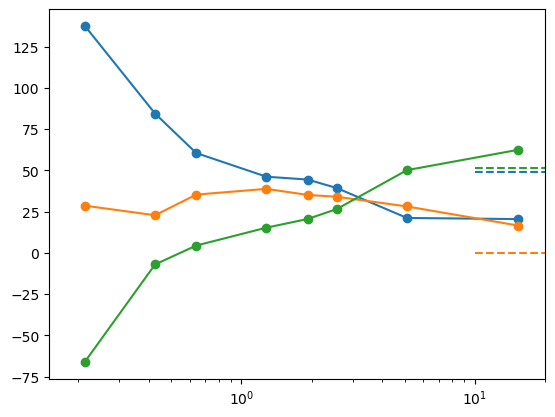

In [65]:
#Calculate steady
cur="100_steady_north"
full = xr.open_dataset(spath+bc+"/"+cur+"/"+"all_cur"+".nc")
data_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")
data_k = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_k"+".nc")
data_th = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec_th"+".nc")
control_advec = xr.open_dataset(spath+bc+"/"+cur+"/"+"advec"+".nc")

#Calculate the contributions

#Calculate the relative contributions
#Calculate the anomalies
anom_advec = 100*(data_advec.hs - control_nc.hs)/control_nc.hs
anom_k = 100*(data_k.hs - control_advec.hs)/control_advec.hs
anom_th = 100*(data_th.hs - control_advec.hs)/control_advec.hs

anom_advec = data_advec.hs - control_nc.hs
anom_k = data_k.hs - data_advec.hs
anom_th = data_th.hs - data_advec.hs

inds = find_phase_inds(data_advec, "north", 0.2)
    
full_anom = full.hs - control_nc.hs
inds = inds[inds<len(full_anom.time)]
varY = full_anom[inds[-1], :, :].var(skipna=True)
covAdvec = xr.cov(anom_advec[inds[-1], :, :], full_anom[inds[-1], :, :])
covK= xr.cov(anom_k[inds[-1], :, :], full_anom[inds[-1], :, :])
covTh= xr.cov(anom_th[inds[-1], :, :], full_anom[inds[-1], :, :])

plt.plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covAdvec"]/impact_df_north["varY"], '-o')
plt.plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covK"]/impact_df_north["varY"], '-o')
plt.plot(impact_df_north["cgT/L"]*.19, 100*impact_df_north["covTh"]/impact_df_north["varY"], '-o')

plt.hlines(y=100*covTh/varY, xmin=10, xmax=20, color='tab:green', linestyles='--')
plt.hlines(y=100*covK/varY, xmin=10, xmax=20, color='tab:orange', linestyles='--')
plt.hlines(y=100*covAdvec/varY, xmin=10, xmax=20, color='tab:blue', linestyles='--')

plt.xscale('log')
plt.xlim(0.15, 20)

In [32]:
control_nc

<xarray.Dataset>
Dimensions:    (longitude: 81, latitude: 81, time: 2161)
Coordinates:
  * longitude  (longitude) float32 210.0 210.1 210.2 210.4 ... 219.8 219.9 220.0
  * latitude   (latitude) float32 -5.0 -4.875 -4.75 -4.625 ... 4.75 4.875 5.0
  * time       (time) datetime64[ns] 2019-06-01 ... 2019-06-16
Data variables:
    MAPSTA     (latitude, longitude) int16 ...
    crs        |S1 ...
    ucur       (time, latitude, longitude) float32 ...
    vcur       (time, latitude, longitude) float32 ...
    uwnd       (time, latitude, longitude) float32 ...
    vwnd       (time, latitude, longitude) float32 ...
    hs         (time, latitude, longitude) float32 ...
    mssu       (time, latitude, longitude) float32 ...
    mssc       (time, latitude, longitude) float32 ...
Attributes: (12/15)
    WAVEWATCH_III_version_number:  7.14
    WAVEWATCH_III_switches:        NOGRB SHRD PR3 UQ FLX0 LN1 ST4 STAB0 NL1 B...
    product_name:                  ww3.2019.nc
    area:                          idealized
    latitude_resolution:           0.
    longitude_resolution:          0.
    ...                            ...
    easternmost_longitude:         220.
    minimum_altitude:              -12000 m
    maximum_altitude:              9000 m
    altitude_resolution:           n/a
    start_date:                    2019-06-01 00:00:00
    stop_date:                     2019-06-16 00:00:00

In [20]:
covTh.values[

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed